# Vehicle Detection

# Preparation

## Import Dataset

In [ ]:
import os

kaggle_path='./API/kaggle.json'
if os.path.exists(kaggle_path):
    print("API Ditemukan")
else:
    print("API Tidak ditemukan")

API Ditemukan


In [ ]:
!kaggle datasets download -d brsdincer/vehicle-detection-image-set -q

In [ ]:
!unzip -q "vehicle-detection-image-set.zip"

## Import Library

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os, shutil
from sklearn.model_selection import train_test_split
import sys
from PIL import Image
from tqdm.notebook import tqdm as tq
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
sys.path.append(os.path.abspath("src"))
from data_loader import create_generators
from model import create_model
from train import train_model
from prediction import predict_images

# Dataset Preparation

## Visualization of Image 

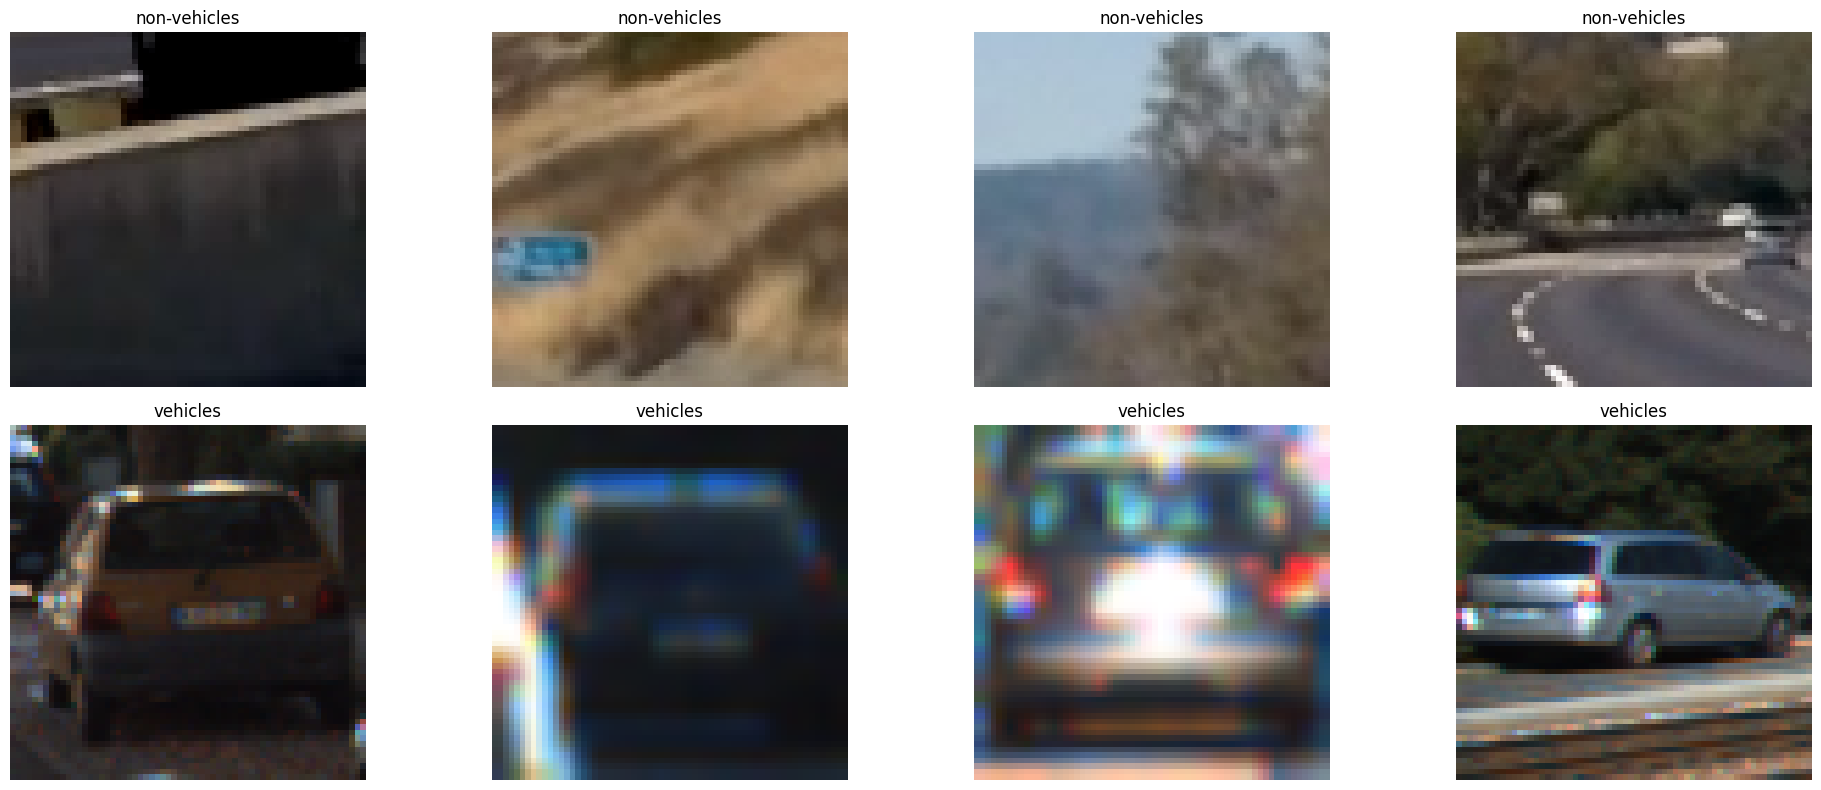

In [9]:
path = "./data"

car = {}
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)
    if os.path.isdir(class_path):
        car[class_name] = os.listdir(class_path)

fig, axes = plt.subplots(len(car), 4, figsize=(20, 4 * len(car)))
if len(car) == 1:
    axes = [axes]

for i, class_name in enumerate(car.keys()):

    images_list = car[class_name]


    num_samples = min(4, len(images_list))


    images = np.random.choice(images_list, num_samples, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path, class_name, image_name)
        img = Image.open(img_path)
        axes[i][j].imshow(img)
        axes[i][j].set_title(class_name)
        axes[i][j].axis('off')

    for k in range(num_samples, 4):
        axes[i][k].axis('off')

plt.tight_layout()
plt.show()

## Distribution of Distribution Image Per Class

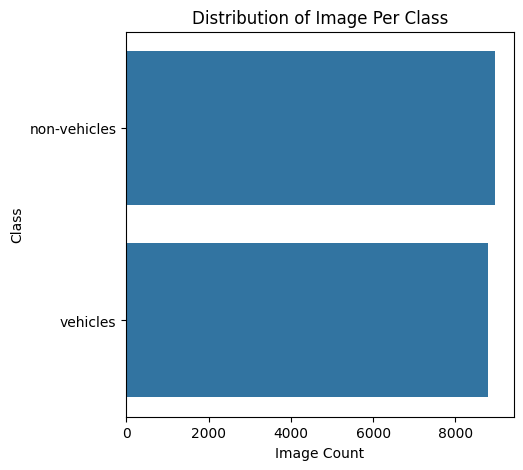

In [10]:
car="./data"
file_name=[]
labels=[]
full_path=[]

for path, subdirs, files in os.walk(car):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

dis_img=pd.DataFrame({"path":full_path, 'file_name':file_name, 'Labels':labels})

plt.figure(figsize=(5,5))
sns.countplot(data=dis_img, y='Labels')
plt.title('Distribution of Image Per Class')
plt.xlabel('Image Count')
plt.ylabel('Class')
plt.show()

## Split Train and Test Data

In [11]:
my_path='./data'
file_name=[]
labels=[]
full_path=[]

for path, subdirs, files in os.walk(my_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

df=pd.DataFrame({"path":full_path, "file_name":file_name, "labels":labels})
df.groupby(['labels']).size()

labels
non-vehicles    8968
vehicles        8792
dtype: int64

In [12]:
X=df['path']
y=df['labels']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
df_tr=pd.DataFrame({'path':X_train, 'labels':y_train, 'set':'train'})
df_ts=pd.DataFrame({'path':X_test, 'labels':y_test, 'set':'test'})

In [14]:
df_all=pd.concat([df_tr, df_ts], ignore_index=False)
print("===============================================\n")
print(df_all.groupby(['set', 'labels']).size(), '\n')
print("===============================================\n")

print(df_all.sample(5))

datasource_path="./data"
dataset_path="./Final"

os.makedirs(dataset_path, exist_ok=True)


set    labels      
test   non-vehicles    1790
       vehicles        1762
train  non-vehicles    7178
       vehicles        7030
dtype: int64 


                                    path        labels    set
3887   ./data\non-vehicles\extra5049.png  non-vehicles   test
6656   ./data\non-vehicles\image2428.png  non-vehicles  train
3964   ./data\non-vehicles\extra5150.png  non-vehicles   test
10409           ./data\vehicles\2299.png      vehicles  train
3381   ./data\non-vehicles\extra4532.png  non-vehicles  train


In [15]:
for index, row in tq(df_all.iterrows()):

    file_path = row['path']


    if not os.path.exists(file_path):
        file_path = os.path.join(
            datasource_path,
            row['labels'],
            row['file_name']
        )


    dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
    os.makedirs(dest_dir, exist_ok=True)


    destination_file_name = os.path.basename(file_path)

    file_dest = os.path.join(dest_dir, destination_file_name)


    if os.path.exists(file_path):
        if not os.path.exists(file_dest):
            shutil.copy2(file_path, file_dest)
    else:
        print("File tidak ditemukan:", file_path)

0it [00:00, ?it/s]

In [9]:
TRAIN_DIR='./Final/train'
TEST_DIR='./Final/test'

train_nonvehicles=os.path.join(TRAIN_DIR + '/non-vehicles')
train_vehicles=os.path.join(TRAIN_DIR +'/vehicles')
test_nonvehicles=os.path.join(TEST_DIR + '/non-vehicles')
test_vehicles=os.path.join(TEST_DIR +'/vehicles')

print("Total Number of Non Vehicles Images in training dataset: ", len(os.listdir(train_nonvehicles)))
print("Total Number of Vehicles Images in training dataset: ", len(os.listdir(train_vehicles)))
print("Total Number of Non Vehicles Images in test dataset: ",len(os.listdir(test_nonvehicles )))
print("Total Number of Vehicles Images in test dataset: ",len(os.listdir(test_vehicles)))

Total Number of Non Vehicles Images in training dataset:  7178
Total Number of Vehicles Images in training dataset:  7030
Total Number of Non Vehicles Images in test dataset:  1790
Total Number of Vehicles Images in test dataset:  1762


# Training Process

## Image Data Generator

In [10]:
train_dir='./Final/train'
test_dir='./Final/test'
train_gen, val_gen, test_gen=create_generators(train_dir, test_dir)

Found 11367 images belonging to 2 classes.
Found 2841 images belonging to 2 classes.
Found 3552 images belonging to 2 classes.


## Modelling

In [11]:
model=create_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 31, 31, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 14, 14, 64)        0

## Train Model

In [12]:
history = train_model(
    model,
    train_gen,
    val_gen,
    train_nonvehicles,
    train_vehicles
)

Epoch 1/10
356/356 [==============================] - 91s 253ms/step - loss: 0.2785 - accuracy: 0.8815 - val_loss: 0.0848 - val_accuracy: 0.9782
Epoch 2/10
356/356 [==============================] - 27s 75ms/step - loss: 0.0907 - accuracy: 0.9667 - val_loss: 0.0379 - val_accuracy: 0.9880
Epoch 3/10
356/356 [==============================] - 26s 73ms/step - loss: 0.0677 - accuracy: 0.9777 - val_loss: 0.0321 - val_accuracy: 0.9891
Epoch 4/10
356/356 [==============================] - 27s 74ms/step - loss: 0.0452 - accuracy: 0.9841 - val_loss: 0.0191 - val_accuracy: 0.9954
Epoch 5/10
356/356 [==============================] - 26s 74ms/step - loss: 0.0483 - accuracy: 0.9838 - val_loss: 0.0097 - val_accuracy: 0.9979
Epoch 6/10
356/356 [==============================] - 26s 74ms/step - loss: 0.0323 - accuracy: 0.9899 - val_loss: 0.0134 - val_accuracy: 0.9951
Epoch 7/10
356/356 [==============================] - 27s 76ms/step - loss: 0.0358 - accuracy: 0.9894 - val_loss: 0.0306 - val_accuracy

# Evaluation

## Data Train Evaluation

In [13]:
loss, accuracy=model.evaluate(train_gen)
print(f"Training Accuracy:{accuracy:.4f}")
print(f"Training Loss:{loss:.4f}")

356/356 [==============================] - 7s 20ms/step - loss: 0.0142 - accuracy: 0.9951
Training Accuracy:0.9951
Training Loss:0.0142


## Data Test Evaluation

In [14]:
loss, accuracy=model.evaluate(test_gen)
print(f"Testing Accuracy:{accuracy:.4f}")
print(f"Testing Loss:{loss:.4f}")

111/111 [==============================] - 20s 185ms/step - loss: 0.0174 - accuracy: 0.9944
Testing Accuracy:0.9944
Testing Loss:0.0174


## Training and Loss Visualize

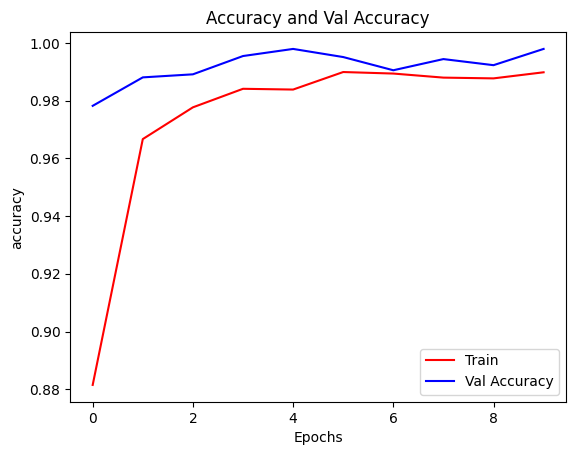

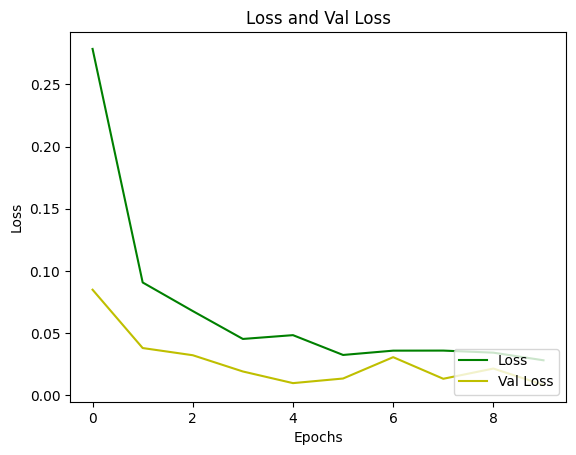

In [15]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc))
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Accuracy and Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend(['Train','Val Accuracy'], loc='lower right')
plt.show()

plt.plot(epochs, loss, 'g')
plt.plot(epochs, val_loss, 'y')
plt.title('Loss and Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss','Val Loss'], loc='lower right')
plt.show()

## Confusion Matrix and Classification Report

111/111 [==============================] - 2s 20ms/step


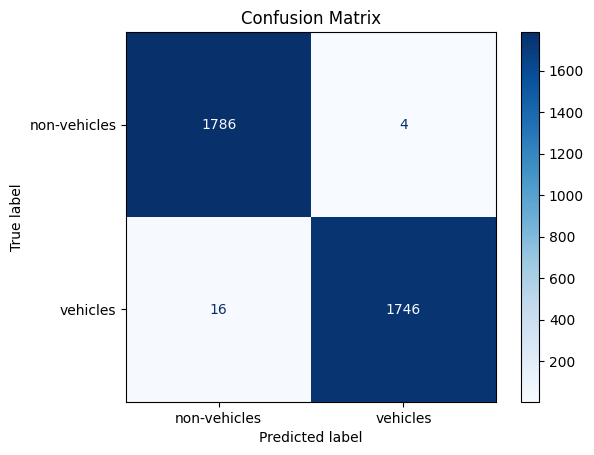

Classification Report:
               precision    recall  f1-score   support

non-vehicles       0.99      1.00      0.99      1790
    vehicles       1.00      0.99      0.99      1762

    accuracy                           0.99      3552
   macro avg       0.99      0.99      0.99      3552
weighted avg       0.99      0.99      0.99      3552



In [16]:
Y_pred = model.predict(test_gen, verbose=1)

y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
class_names = sorted(class_names, key=lambda x: test_gen.class_indices[x])

Cm = confusion_matrix(y_true, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix=Cm, display_labels=class_names)
display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

## Save Model

In [ ]:
os.makedirs('Model')
model.save('./Model/model.h5')

c:\python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Test Model

In [ ]:
model=load_model('./Model/model.h5')
classes=['non-vehicles','vehicles']
test_dir='./Test'
total=0
correct=0
class_stats={
    'vehicles':{'correct':0, 'total':0},
    'non-vehicles':{'correct':0, 'total':0}
}

for label in classes:
    folder_path=os.path.join(test_dir, label)
    for file in os.listdir(folder_path):
        img_path=os.path.join(folder_path, file)

        try:
            pred, conf=predict_images(model, img_path, classes)

            total+=1
            class_stats[label]['total'] +=1

            if pred==label:
                correct +=1
                class_stats[label]['correct']+=1
            print(f"{file} -> Prediksi: {pred} ({conf*100:.2f}%) | Label asli : {label}")
        except Exception as e:
            print(f"Error pada {file}:{e}")


accuracy=correct/total*100

print("\n====Result===")
print(f"Total data:{total}")
print(f'Correct: {correct}')
print(f"Akurasi Total:{accuracy:.2f}%")

for cls in classes:
    cls_correct=class_stats[cls]['correct']
    cls_total=class_stats[cls]['total']
    cls_acc=(cls_correct/ cls_total *100) if cls_total > 0 else 0

    print(f"\nKelas:{cls}")
    print(f"Benar:{cls_correct}/ {cls_total}")
    print(f"Akurasi:{cls_acc:.2f}%")


1/1 [==============================] - 0s 270ms/step
non-vehicles (1).jpeg -> Prediksi: non-vehicles (96.06%) | Label asli : non-vehicles
1/1 [==============================] - 0s 37ms/step
non-vehicles (10).jpeg -> Prediksi: vehicles (61.50%) | Label asli : non-vehicles
1/1 [==============================] - 0s 38ms/step
non-vehicles (11).jpeg -> Prediksi: non-vehicles (100.00%) | Label asli : non-vehicles
1/1 [==============================] - 0s 36ms/step
non-vehicles (12).jpeg -> Prediksi: non-vehicles (99.93%) | Label asli : non-vehicles
1/1 [==============================] - 0s 36ms/step
non-vehicles (13).jpeg -> Prediksi: non-vehicles (100.00%) | Label asli : non-vehicles
1/1 [==============================] - 0s 37ms/step
non-vehicles (14).jpeg -> Prediksi: non-vehicles (99.66%) | Label asli : non-vehicles
1/1 [==============================] - 0s 37ms/step
non-vehicles (15).jpeg -> Prediksi: non-vehicles (99.88%) | Label asli : non-vehicles
1/1 [==============================]